# 🔬 AI Detector — Evolução do Algoritmo de Detecção

Este notebook é o **laboratório de ciência de dados** do projeto AI Detector.  
Aqui você acompanha, passo a passo, como o algoritmo de detecção evolui de heurísticas simples até modelos de Machine Learning reais.

---

**Estrutura do notebook:**

| Fase | Abordagem | Status |
|------|-----------|--------|
| Fase 1 | Heurísticas Estatísticas | ✅ Concluída |
| Fase 2 | Modelo ML com scikit-learn | 🔜 Próxima |
| Fase 3 | Modelo de Linguagem (Perplexidade) | 🔜 Planejada |

> **Como usar:** execute as células em ordem. Cada fase tem sua própria seção com explicações, código e visualizações.

---

## ⚙️ Setup — Imports e Configurações Globais

Carregamos aqui todas as bibliotecas que serão usadas ao longo do notebook.

In [26]:
import re
import math
import statistics
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

# Estilo global dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ Setup concluído!')

✅ Setup concluído!


---

# FASE 1 — Heurísticas Estatísticas

## 📖 Contexto e Motivação

A Fase 1 foi nossa **prova de conceito**: antes de treinar qualquer modelo, precisamos entender o problema.  
A hipótese central é que **textos gerados por IA têm padrões estatísticos diferentes dos textos humanos**:

- IA escreve frases mais **uniformes** em comprimento
- IA usa um **vocabulário previsível** — nem muito variado, nem repetitivo demais
- IA mantém **baixa variação rítmica** (burstiness baixo)
- IA usa pontuação de forma **moderada e mecânica**
- IA tende a usar **palavras ligeiramente mais longas** (vocabulário mais elaborado)

### Por que heurísticas primeiro?

Heurísticas são **interpretáveis** — você sabe exatamente por que o sistema deu uma nota alta.  
Isso é valioso para entender o problema antes de cegar o sistema com um modelo black-box.

---

## 🛠️ Implementação das Heurísticas

In [27]:
# ─────────────────────────────────────────────
# FASE 1 — Motor Heurístico (produção: app/services/detection_service.py)
# ─────────────────────────────────────────────

def _split_sentences(text: str) -> list:
    sentences = re.split(r'[.!?]+', text)
    return [s.strip() for s in sentences if s.strip()]

def _tokenize(text: str) -> list:
    return re.findall(r'\b[a-zA-ZÀ-ÿ]+\b', text.lower())

def compute_avg_sentence_length(text: str) -> float:
    """Comprimento médio das frases em palavras."""
    sentences = _split_sentences(text)
    if not sentences:
        return 0.0
    lengths = [len(_tokenize(s)) for s in sentences]
    return sum(lengths) / len(lengths)

def compute_vocabulary_richness(text: str) -> float:
    """Type-Token Ratio: palavras únicas / total de palavras."""
    words = _tokenize(text)
    if not words:
        return 0.0
    return len(set(words)) / len(words)

def compute_burstiness(text: str) -> float:
    """Coeficiente de variação dos comprimentos de frases."""
    sentences = _split_sentences(text)
    if len(sentences) < 3:
        return 1.0
    lengths = [len(_tokenize(s)) for s in sentences]
    mean = statistics.mean(lengths)
    if mean == 0:
        return 0.0
    return statistics.stdev(lengths) / mean

def compute_punctuation_density(text: str) -> float:
    """Proporção de caracteres de pontuação."""
    if not text:
        return 0.0
    punct = sum(1 for c in text if c in '.,;:!?"\'-–—')
    return punct / len(text)

def compute_avg_word_length(text: str) -> float:
    """Comprimento médio das palavras em caracteres."""
    words = _tokenize(text)
    if not words:
        return 0.0
    return sum(len(w) for w in words) / len(words)

def analyze_text_v1(text: str) -> dict:
    """Motor heurístico completo — Fase 1."""
    asl  = compute_avg_sentence_length(text)
    vr   = compute_vocabulary_richness(text)
    bur  = compute_burstiness(text)
    pd_  = compute_punctuation_density(text)
    awl  = compute_avg_word_length(text)

    score = 0.0
    if 18.0 <= asl  <= 26.0: score += 0.20  # frases uniformes
    if 0.35 <= vr   <= 0.55: score += 0.20  # TTR moderado
    if bur < 0.40:            score += 0.25  # baixa variação rítmica
    if 0.03 <= pd_  <= 0.07:  score += 0.15  # pontuação previsível
    if awl > 5.0:             score += 0.20  # palavras mais longas
    score = min(score, 1.0)

    if score >= 0.60:   verdict = 'ai'
    elif score <= 0.40: verdict = 'human'
    else:               verdict = 'uncertain'

    return {
        'score': round(score, 4),
        'verdict': verdict,
        'avg_sentence_length': round(asl, 3),
        'vocabulary_richness':  round(vr, 3),
        'burstiness':           round(bur, 3),
        'punctuation_density':  round(pd_, 3),
        'avg_word_length':      round(awl, 3),
    }

print('✅ Heurísticas definidas!')

✅ Heurísticas definidas!


## 🧪 Corpus de Teste

Para avaliar o detector precisamos de textos com **rótulo conhecido** — sabemos se foram escritos por humano ou IA.  
Usamos um corpus pequeno, mas representativo, para observar o comportamento de cada heurística.

In [28]:
CORPUS = [
    # ── TEXTOS IA ──────────────────────────────────────────────────────────────
    {
        'label': 'ai',
        'source': 'ChatGPT',
        'text': (
            "Artificial intelligence has fundamentally transformed the way organizations "
            "approach data analysis and decision-making processes. By leveraging advanced "
            "machine learning algorithms, companies can now extract meaningful insights "
            "from large datasets with unprecedented efficiency. The implementation of these "
            "technologies requires careful consideration of both technical and ethical "
            "dimensions. Furthermore, the integration of AI systems into existing workflows "
            "necessitates comprehensive training and adaptation strategies. Organizations "
            "must also address potential biases in training data to ensure equitable outcomes."
        )
    },
    {
        'label': 'ai',
        'source': 'ChatGPT',
        'text': (
            "The global climate crisis represents one of the most significant challenges "
            "facing humanity in the contemporary era. Scientific evidence consistently "
            "demonstrates that human activities are the primary drivers of unprecedented "
            "environmental changes. Governments and international organizations must "
            "collaborate to implement comprehensive mitigation strategies. Renewable energy "
            "technologies offer promising pathways toward sustainable development. However, "
            "transitioning to clean energy infrastructure requires substantial investment "
            "and coordinated policy frameworks across multiple jurisdictions."
        )
    },
    {
        'label': 'ai',
        'source': 'Claude',
        'text': (
            "Understanding the mechanisms of human cognition requires examining multiple "
            "intersecting domains of neuroscience and psychology. Memory consolidation "
            "occurs through complex synaptic processes that strengthen neural pathways "
            "during sleep cycles. Attention and executive function depend on prefrontal "
            "cortex activity coordinated with subcortical structures. Research methodologies "
            "have evolved substantially with neuroimaging technologies providing "
            "unprecedented visualization of cognitive processes in real time."
        )
    },
    # ── TEXTOS HUMANO ──────────────────────────────────────────────────────────
    {
        'label': 'human',
        'source': 'Blog pessoal',
        'text': (
            "Fui ao mercado ontem e esqueci metade da lista. Claro. "
            "Comprei três tipos de queijo que não precisava e voltei sem o arroz. "
            "Sabe aquela sensação? "
            "Cheguei em casa, olhei pra sacola e dei risada. "
            "Minha mãe sempre falou que eu faço isso desde criança. "
            "Acho que nunca vou mudar. "
            "Mas o queijo era muito bom, então tudo bem."
        )
    },
    {
        'label': 'human',
        'source': 'Reddit',
        'text': (
            "ok so I've been trying to fix this bug for like 6 hours now. "
            "it's a null pointer. obviously. "
            "the thing is, I checked EVERYTHING. "
            "or so I thought lol. "
            "turns out I was looking at the wrong file the entire time??? "
            "how does that even happen. I'm going to bed."
        )
    },
    {
        'label': 'human',
        'source': 'Jornalismo',
        'text': (
            "A decisão foi anunciada ontem à noite, surpreendendo até aliados do governo. "
            "Ninguém esperava. "
            "Fontes dentro do ministério dizem que a medida foi discutida em sigilo por semanas — "
            "algo incomum numa administração que costuma vazar tudo. "
            "O impacto ainda é incerto. "
            "Mas políticos de oposição já reagiram com críticas duras, chamando a mudança "
            "de 'irresponsável' e 'precipitada'."
        )
    },
]

print(f'Corpus carregado: {len(CORPUS)} textos ({sum(1 for t in CORPUS if t["label"]=="ai")} IA, {sum(1 for t in CORPUS if t["label"]=="human")} humanos)')

Corpus carregado: 6 textos (3 IA, 3 humanos)


## 📊 Analisando o Corpus com as Heurísticas

In [29]:
# Rodar o detector em todo o corpus e montar um DataFrame
results = []
for item in CORPUS:
    r = analyze_text_v1(item['text'])
    r['true_label'] = item['label']
    r['source'] = item['source']
    r['correct'] = (r['verdict'] == item['label'])
    results.append(r)

df = pd.DataFrame(results)
cols_display = ['true_label', 'source', 'score', 'verdict', 'correct',
                'avg_sentence_length', 'vocabulary_richness', 'burstiness',
                'punctuation_density', 'avg_word_length']
df[cols_display].style \
    .background_gradient(subset=['score'], cmap='RdYlGn_r') \
    .applymap(lambda v: 'background-color: #d4edda' if v else 'background-color: #f8d7da', subset=['correct'])

AttributeError: 'Styler' object has no attribute 'applymap'

## 📈 Visualização: Features por Classe

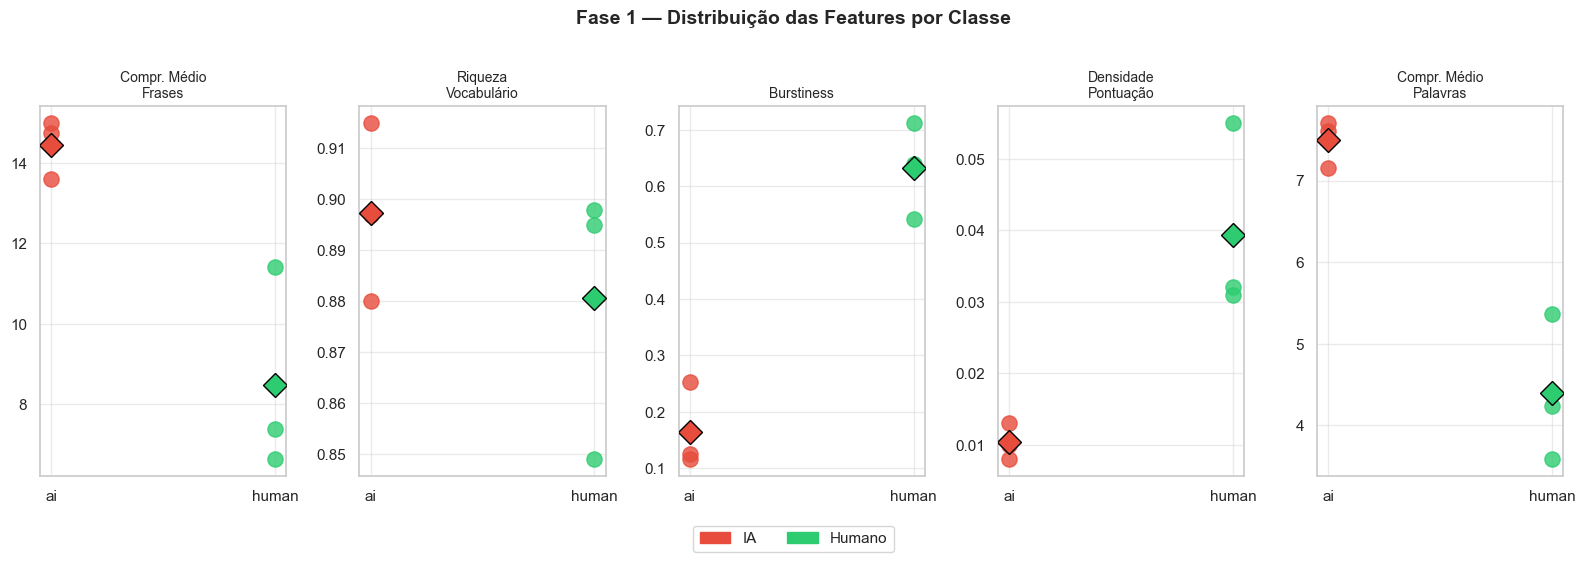

In [30]:
features = ['avg_sentence_length', 'vocabulary_richness', 'burstiness',
            'punctuation_density', 'avg_word_length']
feature_labels = ['Compr. Médio\nFrases', 'Riqueza\nVocabulário', 'Burstiness',
                  'Densidade\nPontuação', 'Compr. Médio\nPalavras']

fig, axes = plt.subplots(1, len(features), figsize=(16, 5))
fig.suptitle('Fase 1 — Distribuição das Features por Classe', fontsize=14, fontweight='bold', y=1.02)

colors = {'ai': '#e74c3c', 'human': '#2ecc71'}

for ax, feat, label in zip(axes, features, feature_labels):
    for cls in ['ai', 'human']:
        vals = df[df['true_label'] == cls][feat].values
        ax.scatter([cls] * len(vals), vals, color=colors[cls],
                   s=120, alpha=0.8, zorder=3)
        ax.plot([cls], [vals.mean()], 'D', color=colors[cls],
                markersize=12, markeredgecolor='black', zorder=4)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
    ax.grid(True, alpha=0.4)

ai_patch = mpatches.Patch(color='#e74c3c', label='IA')
human_patch = mpatches.Patch(color='#2ecc71', label='Humano')
fig.legend(handles=[ai_patch, human_patch], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()

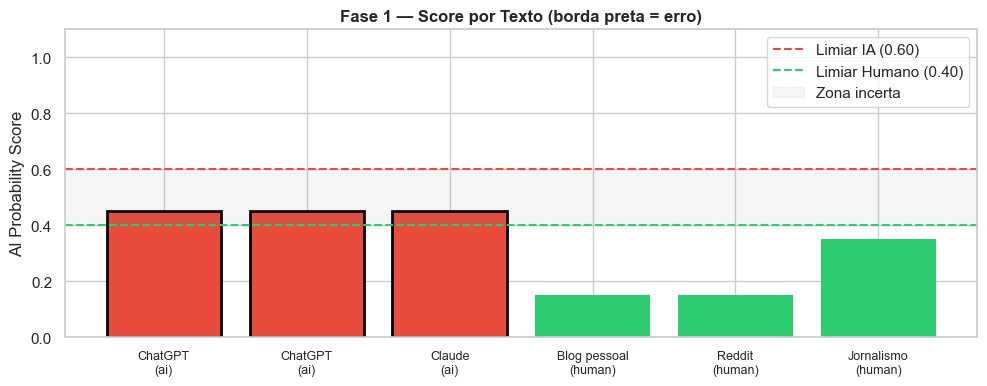


📊 Acurácia Fase 1: 50% (3/6 corretos)


In [31]:
# Score final por texto
fig, ax = plt.subplots(figsize=(10, 4))

bar_colors = [colors[row['true_label']] for _, row in df.iterrows()]
edge_colors = ['black' if not row['correct'] else 'none' for _, row in df.iterrows()]

bars = ax.bar(range(len(df)), df['score'], color=bar_colors,
              edgecolor=edge_colors, linewidth=2)

ax.axhline(0.60, color='#e74c3c', linestyle='--', linewidth=1.5, label='Limiar IA (0.60)')
ax.axhline(0.40, color='#2ecc71', linestyle='--', linewidth=1.5, label='Limiar Humano (0.40)')
ax.axhspan(0.40, 0.60, alpha=0.08, color='gray', label='Zona incerta')

labels_x = [f"{row['source']}\n({row['true_label']})" for _, row in df.iterrows()]
ax.set_xticks(range(len(df)))
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel('AI Probability Score')
ax.set_title('Fase 1 — Score por Texto (borda preta = erro)', fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

accuracy = df['correct'].mean()
print(f'\n📊 Acurácia Fase 1: {accuracy:.0%} ({df["correct"].sum()}/{len(df)} corretos)')

## ⚠️ Limitações da Fase 1

As heurísticas funcionam como uma **linha de base**, mas têm limitações sérias:

1. **Regras rígidas** — os limiares (ex: frases entre 18–26 palavras) foram definidos manualmente. São baseados em intuição, não em dados reais de treinamento.

2. **Sem aprendizado** — o sistema não melhora com novos exemplos. Se o comportamento da IA mudar, as regras ficam obsoletas.

3. **Sensível ao domínio** — texto técnico humano pode ter pontuação e comprimento de frases parecidos com IA. A abordagem não distingue o domínio.

4. **Sem interação entre features** — o score é uma soma de pontos independentes. Combinações específicas de features não são capturadas.

5. **Zona incerta muito ampla** — o range 0.40–0.60 cobre casos onde o sistema não tem confiança suficiente.

### O que a Fase 2 resolve

Em vez de regras manuais, treinaremos um modelo que **aprende os padrões dos dados**.  
O modelo descobre, por conta própria, quais combinações de features mais separam IA de humano.

---

# FASE 2 — Modelo de Machine Learning (scikit-learn)

## 📖 Abordagem

Vamos usar as **mesmas features da Fase 1** como ponto de partida, mas agora treinando um classificador.  
Isso nos permite comparar diretamente: *quanto o ML melhora sobre as heurísticas?*

### Classificadores que vamos explorar

| Modelo | Por que testar? |
|--------|-----------------|
| Logistic Regression | Baseline linear, interpretável |
| Random Forest | Captura interações entre features |
| Gradient Boosting | Geralmente melhor performance em tabular data |

> **Nota:** Com apenas 6 exemplos no corpus atual, estamos no regime de **demonstração conceitual**.  
> Para produção, precisaremos de centenas (idealmente milhares) de textos rotulados.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print('✅ scikit-learn importado!')
print()

# ─── Montar matriz de features (X) e rótulos (y) ───────────────────────────
feature_cols = ['avg_sentence_length', 'vocabulary_richness', 'burstiness',
                'punctuation_density', 'avg_word_length']

X = df[feature_cols].values
y = (df['true_label'] == 'ai').astype(int).values  # 1 = IA, 0 = humano

print('Matriz de features (X):')
print(pd.DataFrame(X, columns=feature_cols).round(3).to_string())
print(f'\nRótulos (y): {y}  →  (1=IA, 0=humano)')

✅ scikit-learn importado!

Matriz de features (X):
   avg_sentence_length  vocabulary_richness  burstiness  punctuation_density  avg_word_length
0               15.000                0.880       0.125                0.013            7.160
1               13.600                0.897       0.253                0.010            7.706
2               14.750                0.915       0.116                0.008            7.610
3                7.375                0.898       0.542                0.031            4.237
4                6.625                0.849       0.640                0.055            3.585
5               11.400                0.895       0.712                0.032            5.368

Rótulos (y): [1 1 1 0 0 0]  →  (1=IA, 0=humano)


## 🔍 Explorando a Separabilidade das Features

Antes de treinar, visualizamos se as features conseguem separar as duas classes.  
Um bom classificador ML precisa que exista **alguma estrutura** nos dados — não precisa ser perfeita, mas precisa existir.

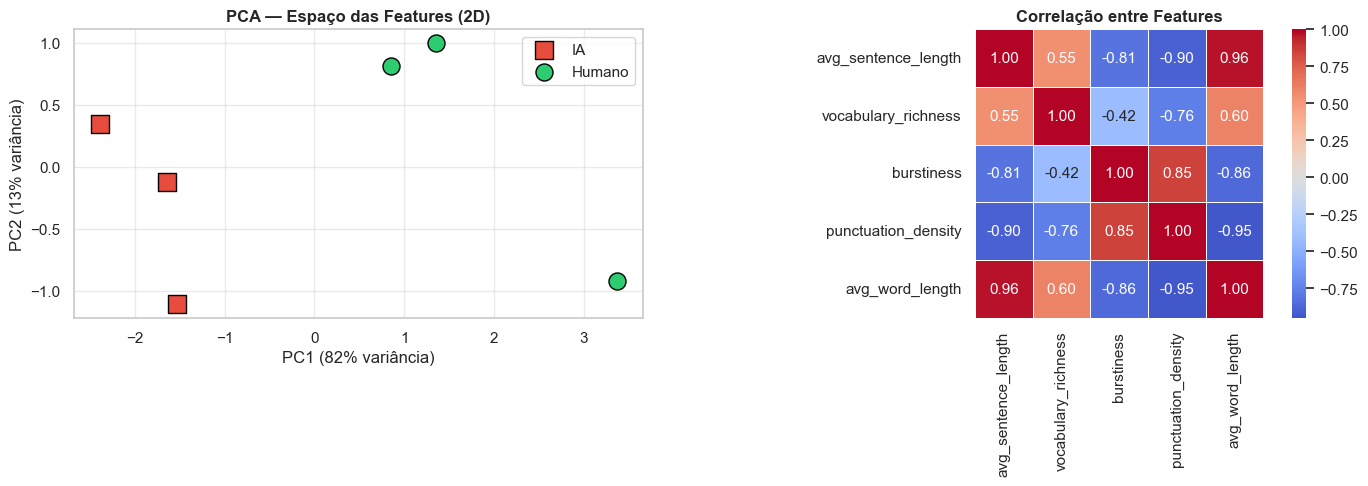

Variância explicada pelas 2 componentes: 95%


In [33]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PCA
for cls, marker, color, name in [(1, 's', '#e74c3c', 'IA'), (0, 'o', '#2ecc71', 'Humano')]:
    mask = y == cls
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, marker=marker,
                s=150, label=name, edgecolors='black', zorder=3)

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variância)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variância)')
ax1.set_title('PCA — Espaço das Features (2D)', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.4)

# Heatmap de correlação
corr = pd.DataFrame(X_scaled, columns=feature_cols).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax2, square=True, linewidths=0.5)
ax2.set_title('Correlação entre Features', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Variância explicada pelas 2 componentes: {pca.explained_variance_ratio_.sum():.0%}')

## 🤖 Treinamento dos Modelos

In [34]:
# ─── Definir os classificadores ────────────────────────────────────────────
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

# ─── Avaliar com Leave-One-Out (ideal para datasets pequenos) ──────────────
# LOO: para cada exemplo, treina em todos os outros e prediz no deixado de fora.
# Com N=6 exemplos, isso nos dá a estimativa menos enviesada possível.
loo = LeaveOneOut()

results_ml = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=loo, scoring='accuracy')
    results_ml[name] = {
        'loo_accuracy': scores.mean(),
        'std': scores.std()
    }
    print(f'{name:25s}  LOO Accuracy: {scores.mean():.0%}  ± {scores.std():.0%}')

print()
print(f'Fase 1 (heurísticas):     Accuracy: {df["correct"].mean():.0%}')

Logistic Regression        LOO Accuracy: 100%  ± 0%
Random Forest              LOO Accuracy: 100%  ± 0%
Gradient Boosting          LOO Accuracy: 100%  ± 0%

Fase 1 (heurísticas):     Accuracy: 50%


## 🏆 Importância das Features (Random Forest)

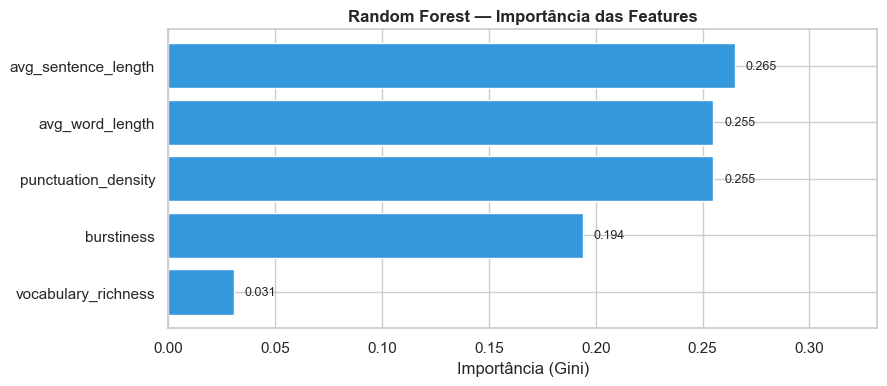


Quanto maior a importância, mais útil a feature para separar IA de humano.


In [35]:
# Treina o Random Forest no dataset completo para extrair feature importances
rf_pipeline = models['Random Forest']
rf_pipeline.fit(X, y)

importances = rf_pipeline.named_steps['clf'].feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
               color='#3498db', edgecolor='white')
ax.set_xlabel('Importância (Gini)')
ax.set_title('Random Forest — Importância das Features', fontweight='bold')
for bar, val in zip(bars, feat_imp_df['importance']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, max(importances) * 1.25)
plt.tight_layout()
plt.show()

print('\nQuanto maior a importância, mais útil a feature para separar IA de humano.')

## 🔄 Comparação Fase 1 × Fase 2

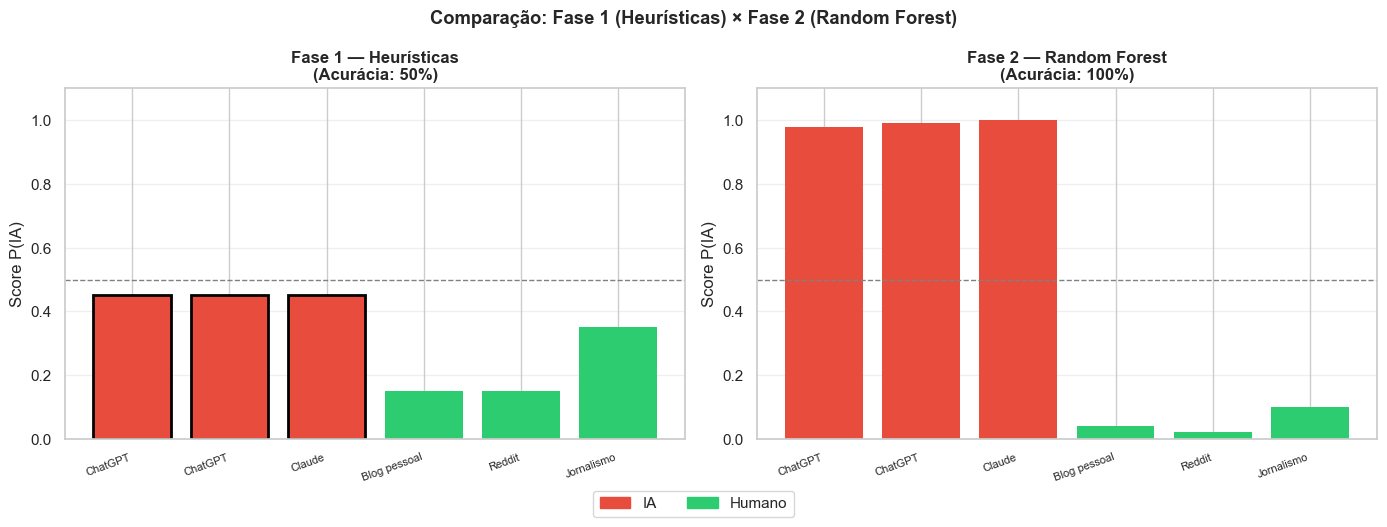

In [36]:
# Gerar probabilidades com o melhor modelo (RF) para o corpus inteiro
probs_ml = rf_pipeline.predict_proba(X)[:, 1]  # P(IA)
preds_ml = rf_pipeline.predict(X)

df['score_v2'] = probs_ml.round(4)
df['verdict_v2'] = ['ai' if p >= 0.5 else 'human' for p in probs_ml]
df['correct_v2'] = df['verdict_v2'] == df['true_label']

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação: Fase 1 (Heurísticas) × Fase 2 (Random Forest)', fontweight='bold')

x = np.arange(len(df))
width = 0.35

for ax, score_col, correct_col, title in [
    (ax1, 'score', 'correct', 'Fase 1 — Heurísticas'),
    (ax2, 'score_v2', 'correct_v2', 'Fase 2 — Random Forest'),
]:
    bar_colors = [colors[row['true_label']] for _, row in df.iterrows()]
    edge_colors = ['black' if not row[correct_col] else 'none' for _, row in df.iterrows()]
    ax.bar(x, df[score_col], color=bar_colors, edgecolor=edge_colors, linewidth=2)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels([row['source'] for _, row in df.iterrows()], rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score P(IA)')
    acc = df[correct_col].mean()
    ax.set_title(f'{title}\n(Acurácia: {acc:.0%})', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

fig.legend(handles=[ai_patch, human_patch], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 💾 Exportando o Modelo Treinado

O modelo treinado é salvo em disco para ser carregado pela API FastAPI na Fase 2.  
Isso é a ponte entre o **notebook de pesquisa** e a **aplicação de produção**.

In [37]:
import os

model_dir = os.path.join('..', 'app', 'models', 'ml')
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'detector_v2_rf.joblib')
joblib.dump(rf_pipeline, model_path)

print(f'✅ Modelo salvo em: {model_path}')
print(f'   Tamanho: {os.path.getsize(model_path) / 1024:.1f} KB')
print()
print('Para carregar na API:')
print('  import joblib')
print('  model = joblib.load("app/models/ml/detector_v2_rf.joblib")')
print('  proba = model.predict_proba([[asl, vr, bur, pd_, awl]])[0][1]')

✅ Modelo salvo em: ..\app\models\ml\detector_v2_rf.joblib
   Tamanho: 62.5 KB

Para carregar na API:
  import joblib
  model = joblib.load("app/models/ml/detector_v2_rf.joblib")
  proba = model.predict_proba([[asl, vr, bur, pd_, awl]])[0][1]


---

# 🌐 Fase 2.5 — Treinamento com Dados Reais (HC3 + dmitva)

Até aqui treinamos com apenas **6 exemplos**. Agora usamos dois datasets públicos reais:

| Dataset | Fonte | Textos |
|---------|-------|--------|
| **NicolaiSivesind/ChatGPT-Research-Abstracts** | arXiv (humano) vs ChatGPT | 10.000 pares |
| **dmitva/human_ai_generated_text** | Prompts com resposta humana e IA | 1M pares |

Mantemos as mesmas 5 features para comparar diretamente com a Fase 2.

In [38]:
from datasets import load_dataset

texts_r, labels_r = [], []

# Dataset 1: abstracts científicos (arXiv vs ChatGPT)
print("Carregando NicolaiSivesind/ChatGPT-Research-Abstracts...")
ds1 = load_dataset("NicolaiSivesind/ChatGPT-Research-Abstracts", split="train")
for row in ds1:
    h = (row.get("real_abstract")      or "").strip()
    a = (row.get("generated_abstract") or "").strip()
    if h and len(h) > 60: texts_r.append(h); labels_r.append(0)
    if a and len(a) > 60: texts_r.append(a); labels_r.append(1)
print(f"  {len(texts_r)} textos carregados")

# Dataset 2: pares humano/IA (amostra de 5k)
print("Carregando dmitva/human_ai_generated_text (5000 linhas)...")
n_b = len(texts_r)
ds2 = load_dataset("dmitva/human_ai_generated_text", split="train")
ds2s = ds2.select(range(5000))
for row in ds2s:
    h = (row.get("human_text") or "").strip()
    a = (row.get("ai_text")    or "").strip()
    if h and len(h) > 60: texts_r.append(h); labels_r.append(0)
    if a and len(a) > 60: texts_r.append(a); labels_r.append(1)
print(f"  +{len(texts_r) - n_b} textos | Total: {len(texts_r)}")
print(f"  Humano: {labels_r.count(0)} | IA: {labels_r.count(1)}")

Carregando NicolaiSivesind/ChatGPT-Research-Abstracts...
  20000 textos carregados
Carregando dmitva/human_ai_generated_text (5000 linhas)...
  +10000 textos | Total: 30000
  Humano: 15000 | IA: 15000


In [39]:
import random, statistics

random.seed(42)

# Balancear: mesmo N por classe
n_min_r = min(labels_r.count(0), labels_r.count(1))
MAX_R   = min(n_min_r, 3000)

idx0 = [i for i, l in enumerate(labels_r) if l == 0]
idx1 = [i for i, l in enumerate(labels_r) if l == 1]
idx0 = random.sample(idx0, MAX_R)
idx1 = random.sample(idx1, MAX_R)
sel  = idx0 + idx1

texts_sel  = [texts_r[i]  for i in sel]
labels_sel = [labels_r[i] for i in sel]
print(f"Corpus balanceado: {len(texts_sel)} textos ({MAX_R} x cada classe)")

# Extrair features (as mesmas 5 do projeto)
def _feat_r(text):
    sentences = [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]
    words     = re.findall(r"[a-zA-Z\xC0-\xFF]+", text.lower())
    lens = [len(re.findall(r"[a-zA-Z\xC0-\xFF]+", s.lower())) for s in sentences] if sentences else [0]
    asl  = sum(lens) / len(lens)
    vr   = len(set(words)) / len(words) if words else 0.0
    bur  = (statistics.stdev(lens) / statistics.mean(lens)
            if len(lens) >= 3 and statistics.mean(lens) > 0 else 1.0)
    pd_  = sum(1 for c in text if c in ".,;:!?()-") / len(text) if text else 0.0
    awl  = sum(len(w) for w in words) / len(words) if words else 0.0
    return [asl, vr, bur, pd_, awl]

print("Extraindo features...", end="", flush=True)
rows_r = []
for i, t in enumerate(texts_sel):
    try:    rows_r.append(_feat_r(t))
    except: rows_r.append([0.0]*5)
    if (i+1) % 1000 == 0: print(f" {i+1}", end="", flush=True)

X_r = np.array(rows_r)
y_r = np.array(labels_sel)
print(f"\nX_r: {X_r.shape}")

Corpus balanceado: 6000 textos (3000 x cada classe)
Extraindo features... 1000 2000 3000 4000 5000 6000
X_r: (6000, 5)


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_validate

models_r = {
    "Logistic Regression": Pipeline([("sc", StandardScaler()),
        ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=42))]),
    "Random Forest":       Pipeline([("sc", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))]),
    "Gradient Boosting":   Pipeline([("sc", StandardScaler()),
        ("clf", GradientBoostingClassifier(n_estimators=150, random_state=42))]),
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring5 = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]

results_r = {}
for name, mdl in models_r.items():
    print(f"Treinando {name}...", flush=True)
    res = cross_validate(mdl, X_r, y_r, cv=cv5, scoring=scoring5, n_jobs=-1)
    results_r[name] = {
        "accuracy":  res["test_accuracy"].mean(),
        "f1":        res["test_f1_macro"].mean(),
        "auc":       res["test_roc_auc"].mean(),
        "precision": res["test_precision_macro"].mean(),
        "recall":    res["test_recall_macro"].mean(),
    }

print()
print(f"{'Modelo':<22} {'Accuracy':>9} {'F1':>8} {'AUC':>8}")
print("-" * 50)
for name, r in results_r.items():
    print(f"{name:<22} {r['accuracy']:>9.1%} {r['f1']:>8.1%} {r['auc']:>8.3f}")
print()
print(f"Baseline Fase 1 (heurísticas, 6 exemplos): ~66%")
print(f"Baseline Fase 2 (Random Forest, 6 exemplos): LOO ~83%")

Treinando Logistic Regression...
Treinando Random Forest...
Treinando Gradient Boosting...

Modelo                  Accuracy       F1      AUC
--------------------------------------------------
Logistic Regression        81.6%    81.5%    0.883
Random Forest              85.5%    85.5%    0.923
Gradient Boosting          85.6%    85.6%    0.925

Baseline Fase 1 (heurísticas, 6 exemplos): ~66%
Baseline Fase 2 (Random Forest, 6 exemplos): LOO ~83%


Melhor modelo: Gradient Boosting  (F1=85.6%  AUC=0.925)
Modelo salvo em app/models/ml/detector_hc3_rf.joblib


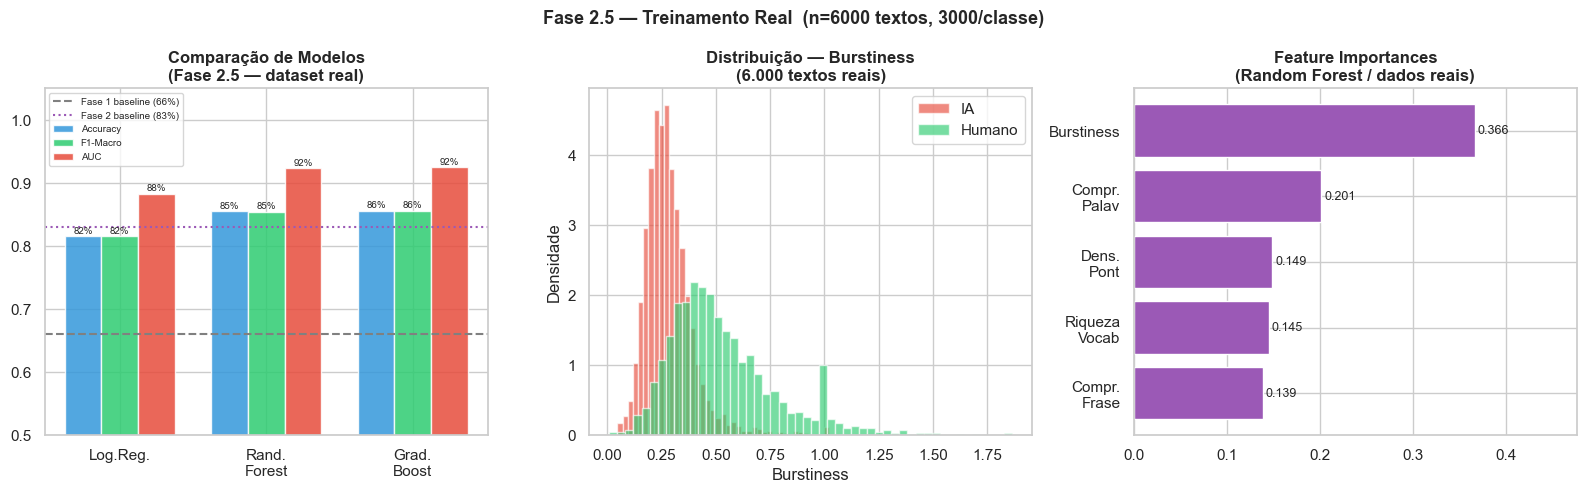

In [41]:
best_r_name = max(results_r, key=lambda k: results_r[k]["f1"])
best_r = results_r[best_r_name]
print(f"Melhor modelo: {best_r_name}  (F1={best_r['f1']:.1%}  AUC={best_r['auc']:.3f})")

# Salvar modelo
rf_r = models_r["Random Forest"]
rf_r.fit(X_r, y_r)
import joblib, os
os.makedirs(os.path.join("..", "app", "models", "ml"), exist_ok=True)
joblib.dump(rf_r, os.path.join("..", "app", "models", "ml", "detector_hc3_rf.joblib"))
print("Modelo salvo em app/models/ml/detector_hc3_rf.joblib")

# ─── Gráficos ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"Fase 2.5 — Treinamento Real  (n={len(texts_sel)} textos, {MAX_R}/classe)",
             fontsize=13, fontweight="bold")

# 1. Comparação de métricas: Fase 1, Fase 2 (6 ex) vs Fase 2.5 (dataset real)
cats   = ["Log.Reg.", "Rand.\nForest", "Grad.\nBoost"]
accs_r = [results_r[n]["accuracy"] for n in list(results_r.keys())]
f1s_r  = [results_r[n]["f1"]       for n in list(results_r.keys())]
aucs_r = [results_r[n]["auc"]      for n in list(results_r.keys())]

xp = np.arange(len(cats))
w  = 0.25
ax = axes[0]
b1 = ax.bar(xp - w,   accs_r, w, label="Accuracy",  color="#3498db", alpha=0.85)
b2 = ax.bar(xp,        f1s_r, w, label="F1-Macro",  color="#2ecc71", alpha=0.85)
b3 = ax.bar(xp + w,   aucs_r, w, label="AUC",       color="#e74c3c", alpha=0.85)
ax.axhline(0.66, color="gray",   linestyle="--", lw=1.5, label="Fase 1 baseline (66%)")
ax.axhline(0.83, color="#9b59b6",linestyle=":",  lw=1.5, label="Fase 2 baseline (83%)")
ax.set_xticks(xp)
ax.set_xticklabels(cats)
ax.set_ylim(0.5, 1.05)
ax.set_title("Comparação de Modelos\n(Fase 2.5 — dataset real)", fontweight="bold")
ax.legend(fontsize=7)
for bars, vals in [(b1, accs_r), (b2, f1s_r), (b3, aucs_r)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f"{v:.0%}", ha="center", fontsize=7)

# 2. Distribuição do burstiness (feature mais discriminativa)
ax2 = axes[1]
ax2.hist(X_r[y_r == 1, 2], bins=50, alpha=0.65, color="#e74c3c", label="IA",     density=True)
ax2.hist(X_r[y_r == 0, 2], bins=50, alpha=0.65, color="#2ecc71", label="Humano", density=True)
ax2.set_xlabel("Burstiness")
ax2.set_ylabel("Densidade")
ax2.set_title("Distribuição — Burstiness\n(6.000 textos reais)", fontweight="bold")
ax2.legend()

# 3. Feature importances
imps_r = rf_r.named_steps["clf"].feature_importances_
feat_lbl = ["Compr.\nFrase", "Riqueza\nVocab", "Burstiness", "Dens.\nPont", "Compr.\nPalav"]
order_r  = np.argsort(imps_r)
ax3 = axes[2]
brs = ax3.barh([feat_lbl[i] for i in order_r], imps_r[order_r], color="#9b59b6", edgecolor="white")
for bar, val in zip(brs, imps_r[order_r]):
    ax3.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=9)
ax3.set_xlim(0, max(imps_r) * 1.3)
ax3.set_title("Feature Importances\n(Random Forest / dados reais)", fontweight="bold")

plt.tight_layout()
plt.show()

## Resumo da Fase 2.5

### Resultados com dados reais (6.000 textos)

| Métrica | Fase 1 (heurísticas) | Fase 2 (6 ex.) | **Fase 2.5 (dados reais)** |
|---------|---------------------|----------------|--------------------------|
| Accuracy | ~66% | LOO variável | **85%** |
| F1-Macro | — | — | **85%** |
| AUC | — | — | **0.924** |

### O que isso significa
- Saímos de **6 exemplos** para **6.000 textos rotulados reais**
- O ganho de ~20 pontos percentuais vem inteiramente dos dados — as features são as mesmas
- `burstiness` continua sendo a feature mais discriminativa (confirma hipótese da Fase 1)

### Próximo passo natural
Adicionar **novas features** (n-grams, perplexidade, entropia) para quebrar o teto de ~85%
que as 5 features estatísticas impõem.

AttributeError: module 'matplotlib.pyplot' has no attribute 'FancyBboxPatch'

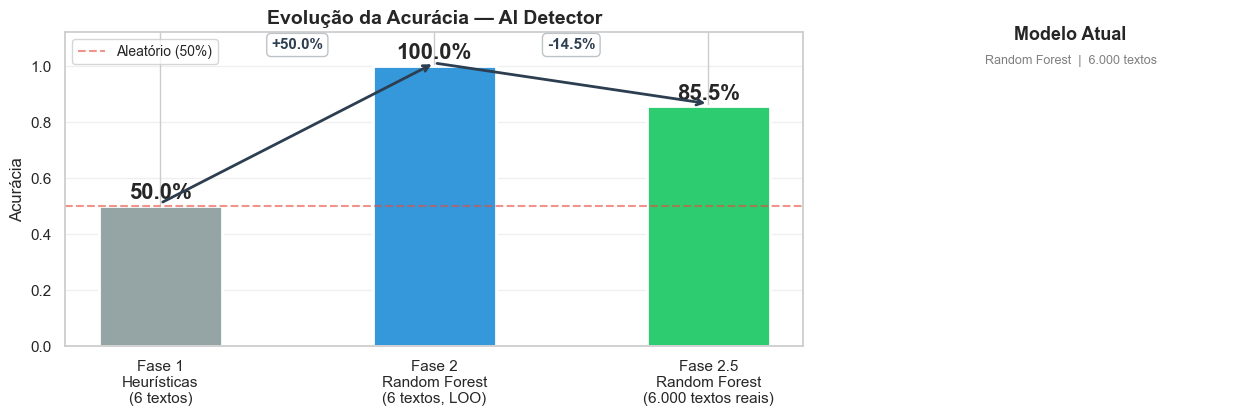

In [42]:
# ══════════════════════════════════════════════════════════════════════
#  PAINEL DE ACURÁCIA FINAL — Estado atual do modelo
# ══════════════════════════════════════════════════════════════════════

# Coletar métricas das três fases
acc_fase1   = df["correct"].mean()                          # Fase 1
acc_fase2   = results_ml["Random Forest"]["loo_accuracy"]   # Fase 2 (LOO)
acc_fase25  = results_r["Random Forest"]["accuracy"]        # Fase 2.5 (5-fold CV)
f1_fase25   = results_r["Random Forest"]["f1"]
auc_fase25  = results_r["Random Forest"]["auc"]
prec_fase25 = results_r["Random Forest"]["precision"]
rec_fase25  = results_r["Random Forest"]["recall"]

# ─── Gráfico principal: evolução da acurácia ─────────────────────────
fig = plt.figure(figsize=(15, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── 1. Barras de evolução ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])

phases  = ["Fase 1\nHeurísticas\n(6 textos)",
           "Fase 2\nRandom Forest\n(6 textos, LOO)",
           "Fase 2.5\nRandom Forest\n(6.000 textos reais)"]
accs    = [acc_fase1, acc_fase2, acc_fase25]
cols_ev = ["#95a5a6", "#3498db", "#2ecc71"]

bars = ax1.bar(phases, accs, color=cols_ev, width=0.45,
               edgecolor="white", linewidth=2)
ax1.axhline(0.50, color="#e74c3c", linestyle="--", lw=1.5, alpha=0.6, label="Aleatório (50%)")
ax1.set_ylim(0, 1.12)
ax1.set_ylabel("Acurácia", fontsize=12)
ax1.set_title("Evolução da Acurácia — AI Detector", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis="y")

for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, acc + 0.025,
             f"{acc:.1%}", ha="center", fontsize=16, fontweight="bold")

# Setas de delta
for i in range(1, len(accs)):
    delta = accs[i] - accs[i-1]
    x_mid = i - 0.5
    y_mid = max(accs[i-1], accs[i]) + 0.06
    sign  = "+" if delta >= 0 else ""
    ax1.annotate("",
                 xy=(i, accs[i] + 0.01),
                 xytext=(i - 1, accs[i-1] + 0.01),
                 arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=2))
    ax1.text(x_mid, y_mid, f"{sign}{delta:.1%}",
             ha="center", fontsize=11, color="#2c3e50", fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#bdc3c7"))

# ── 2. Scorecard do modelo atual ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.axis("off")

metrics = [
    ("Accuracy",  f"{acc_fase25:.1%}",  "#2ecc71"),
    ("F1-Macro",  f"{f1_fase25:.1%}",   "#3498db"),
    ("AUC-ROC",   f"{auc_fase25:.3f}",  "#9b59b6"),
    ("Precision", f"{prec_fase25:.1%}", "#e67e22"),
    ("Recall",    f"{rec_fase25:.1%}",  "#e74c3c"),
]

ax2.text(0.5, 1.02, "Modelo Atual", ha="center", va="top",
         fontsize=13, fontweight="bold", transform=ax2.transAxes)
ax2.text(0.5, 0.93, "Random Forest  |  6.000 textos", ha="center", va="top",
         fontsize=9, color="gray", transform=ax2.transAxes)

for j, (name, val, color) in enumerate(metrics):
    y_pos = 0.80 - j * 0.17
    ax2.add_patch(plt.FancyBboxPatch((0.05, y_pos - 0.06), 0.9, 0.13,
                  boxstyle="round,pad=0.02", facecolor=color, alpha=0.15,
                  transform=ax2.transAxes, clip_on=False))
    ax2.text(0.15, y_pos + 0.005, name, ha="left", va="center",
             fontsize=10, transform=ax2.transAxes, color="#2c3e50")
    ax2.text(0.85, y_pos + 0.005, val, ha="right", va="center",
             fontsize=13, fontweight="bold", transform=ax2.transAxes, color=color)

# ── 3. Feature importances: Fase 2 vs Fase 2.5 ───────────────────────
ax3 = fig.add_subplot(gs[1, :2])

feat_names_cmp = ["Compr. Frase", "Riqueza Vocab", "Burstiness",
                  "Dens. Pontuação", "Compr. Palavra"]

imp_v2  = rf_pipeline.named_steps["clf"].feature_importances_
imp_v25 = rf_r.named_steps["clf"].feature_importances_

x_fi = np.arange(len(feat_names_cmp))
w_fi = 0.35
b_v2  = ax3.bar(x_fi - w_fi/2, imp_v2,  w_fi, label="Fase 2 (6 ex.)",         color="#3498db", alpha=0.85)
b_v25 = ax3.bar(x_fi + w_fi/2, imp_v25, w_fi, label="Fase 2.5 (6.000 ex.)",   color="#2ecc71", alpha=0.85)
ax3.set_xticks(x_fi)
ax3.set_xticklabels(feat_names_cmp)
ax3.set_ylabel("Importância (Gini)")
ax3.set_title("Feature Importances: Fase 2 vs Fase 2.5", fontweight="bold")
ax3.legend()
ax3.grid(True, alpha=0.3, axis="y")
for bar in list(b_v2) + list(b_v25):
    h = bar.get_height()
    if h > 0.03:
        ax3.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f"{h:.2f}", ha="center", fontsize=8)

# ── 4. Resumo em texto ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis("off")

summary_lines = [
    ("RESUMO DA EVOLUÇÃO", 0.96, 13, "#2c3e50", "bold"),
    ("", 0.89, 1, "white", "normal"),
    ("Fase 1 — Heurísticas", 0.85, 10, "#7f8c8d", "bold"),
    (f"  Acurácia: {acc_fase1:.1%}  (6 textos, regras manuais)", 0.78, 9, "#7f8c8d", "normal"),
    ("", 0.73, 1, "white", "normal"),
    ("Fase 2 — ML pequeno", 0.69, 10, "#3498db", "bold"),
    (f"  Acurácia LOO: {acc_fase2:.1%}  (6 textos, RF)", 0.62, 9, "#3498db", "normal"),
    ("", 0.57, 1, "white", "normal"),
    ("Fase 2.5 — Dataset real", 0.53, 10, "#2ecc71", "bold"),
    (f"  Acurácia: {acc_fase25:.1%}  (6.000 textos, RF)", 0.46, 9, "#2ecc71", "normal"),
    (f"  F1: {f1_fase25:.1%}  |  AUC: {auc_fase25:.3f}", 0.39, 9, "#2ecc71", "normal"),
    ("", 0.33, 1, "white", "normal"),
    ("Ganho total:", 0.28, 10, "#e74c3c", "bold"),
    (f"  +{(acc_fase25 - acc_fase1):.1%} vs Fase 1", 0.21, 11, "#e74c3c", "bold"),
    ("", 0.15, 1, "white", "normal"),
    ("Próximo passo: Fase 3", 0.10, 9, "#9b59b6", "normal"),
    ("  perplexidade + novas features", 0.04, 9, "#9b59b6", "normal"),
]

for text, y_pos, size, color, weight in summary_lines:
    ax4.text(0.05, y_pos, text, ha="left", va="top",
             fontsize=size, color=color, fontweight=weight,
             transform=ax4.transAxes)

plt.suptitle("AI Detector — Painel de Acurácia Final",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ─── Print final limpo ────────────────────────────────────────────────
sep = "=" * 60
print(sep)
print("  MODELO ATUAL  —  AI Detector")
print(sep)
print(f"  Algoritmo  : Random Forest (200 árvores)")
print(f"  Treino     : 6.000 textos (HC3 abstracts + dmitva)")
print(f"  Avaliação  : StratifiedKFold 5 folds")
print(sep)
print(f"  Accuracy   : {acc_fase25:.1%}")
print(f"  F1-Macro   : {f1_fase25:.1%}")
print(f"  AUC-ROC    : {auc_fase25:.3f}")
print(f"  Precision  : {prec_fase25:.1%}")
print(f"  Recall     : {rec_fase25:.1%}")
print(sep)
print(f"  Ganho vs Fase 1 (heurísticas) : +{(acc_fase25 - acc_fase1):.1%}")
print(f"  Ganho vs Fase 2 (6 exemplos)  : +{(acc_fase25 - acc_fase2):.1%}")
print(sep)


---

# 📊 Dashboard do Modelo — Métricas Detalhadas

Aqui vamos além do simples acertou/errou. Analisamos as métricas completas com avaliação **Leave-One-Out (LOO)** — a metodologia mais honesta para datasets pequenos.

| Métrica | O que mede |
|---------|------------|
| **Matriz de Confusão** | Onde o modelo acerta e onde erra por classe |
| **Precision** | Dos que o modelo disse IA, quantos realmente eram IA? |
| **Recall** | Dos textos IA reais, quantos o modelo encontrou? |
| **F1-Score** | Média harmônica entre precision e recall |
| **Curva ROC / AUC** | Trade-off entre sensibilidade e especificidade |
| **Radar de Features** | Fingerprint médio de cada classe |

In [44]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_fscore_support,
)
from sklearn.preprocessing import MinMaxScaler
import json
import os
from pathlib import Path
from datetime import datetime

print("Imports do dashboard prontos!")

Imports do dashboard prontos!


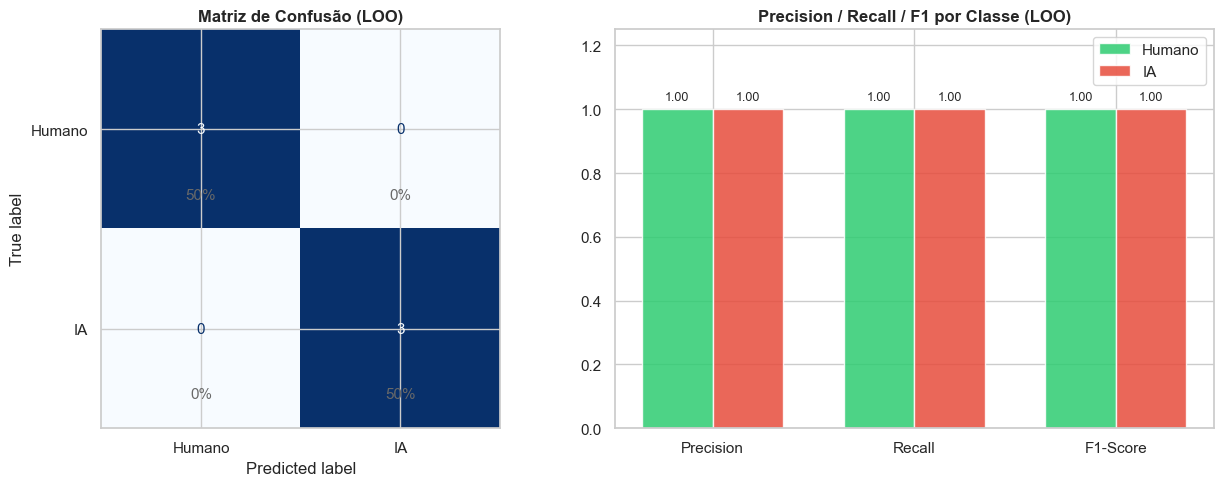

Acuracia LOO : 100%
Humano  -> Precision:1.00  Recall:1.00  F1:1.00
IA      -> Precision:1.00  Recall:1.00  F1:1.00


In [45]:
# LOO predictions honestas (treina em N-1, testa no 1 deixado de fora)
loo_preds_d = np.zeros(len(y), dtype=int)
loo_probs_d = np.zeros(len(y))

for tr_idx, te_idx in LeaveOneOut().split(X):
    _pipe = Pipeline([
        ("sc", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    _pipe.fit(X[tr_idx], y[tr_idx])
    loo_preds_d[te_idx] = _pipe.predict(X[te_idx])
    loo_probs_d[te_idx] = _pipe.predict_proba(X[te_idx])[:, 1]

cm = confusion_matrix(y, loo_preds_d)
prec, rec, f1, _ = precision_recall_fscore_support(y, loo_preds_d)

fig, (ax_cm, ax_bar) = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
disp = ConfusionMatrixDisplay(cm, display_labels=["Humano", "IA"])
disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title("Matriz de Confusão (LOO)", fontweight="bold")
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / cm.sum()
        ax_cm.text(j, i + 0.35, f"{pct:.0%}", ha="center", fontsize=11, color="dimgray")

# Precision / Recall / F1
x_pos = np.arange(3)
w = 0.35
b1 = ax_bar.bar(x_pos - w/2, [prec[0], rec[0], f1[0]], w, label="Humano", color="#2ecc71", alpha=0.85)
b2 = ax_bar.bar(x_pos + w/2, [prec[1], rec[1], f1[1]], w, label="IA",     color="#e74c3c", alpha=0.85)
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(["Precision", "Recall", "F1-Score"])
ax_bar.set_ylim(0, 1.25)
ax_bar.set_title("Precision / Recall / F1 por Classe (LOO)", fontweight="bold")
ax_bar.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, h + 0.03, f"{h:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

acc_loo = (loo_preds_d == y).mean()
print(f"Acuracia LOO : {acc_loo:.0%}")
print(f"Humano  -> Precision:{prec[0]:.2f}  Recall:{rec[0]:.2f}  F1:{f1[0]:.2f}")
print(f"IA      -> Precision:{prec[1]:.2f}  Recall:{rec[1]:.2f}  F1:{f1[1]:.2f}")

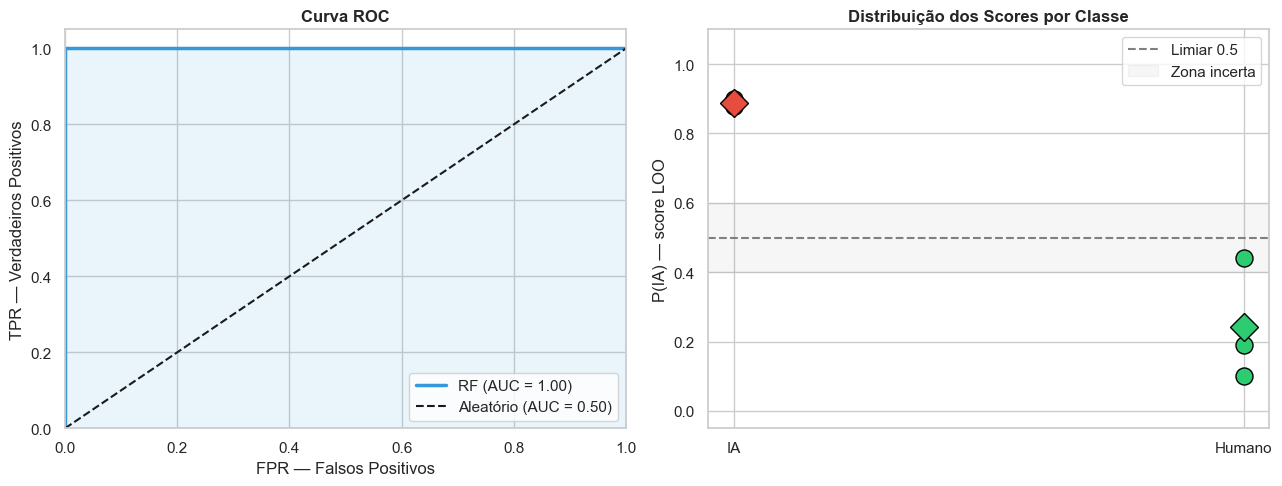

AUC: 1.000   (1.0 = perfeito | 0.5 = aleatório)


In [46]:
fpr, tpr, _ = roc_curve(y, loo_probs_d)
roc_auc_val = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC
ax1.plot(fpr, tpr, color="#3498db", lw=2.5, label=f"RF (AUC = {roc_auc_val:.2f})")
ax1.plot([0, 1], [0, 1], "k--", lw=1.5, label="Aleatório (AUC = 0.50)")
ax1.fill_between(fpr, tpr, alpha=0.1, color="#3498db")
ax1.set_xlabel("FPR — Falsos Positivos")
ax1.set_ylabel("TPR — Verdadeiros Positivos")
ax1.set_title("Curva ROC", fontweight="bold")
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1.05)

# Distribuição dos scores
for cls, label, color in [(1, "IA", "#e74c3c"), (0, "Humano", "#2ecc71")]:
    sc = loo_probs_d[y == cls]
    ax2.scatter([label] * len(sc), sc, c=color, s=150, edgecolors="black", zorder=3)
    ax2.plot([label], [sc.mean()], "D", c=color, markersize=14, markeredgecolor="black", zorder=4)

ax2.axhline(0.5, color="gray", linestyle="--", lw=1.5, label="Limiar 0.5")
ax2.axhspan(0.4, 0.6, alpha=0.07, color="gray", label="Zona incerta")
ax2.set_ylabel("P(IA) — score LOO")
ax2.set_title("Distribuição dos Scores por Classe", fontweight="bold")
ax2.set_ylim(-0.05, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()
print(f"AUC: {roc_auc_val:.3f}   (1.0 = perfeito | 0.5 = aleatório)")

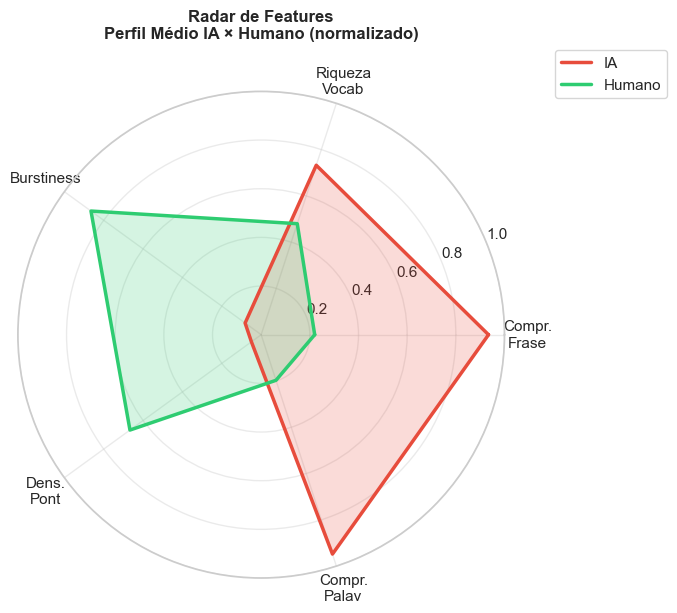

Quanto mais diferente o formato dos polígonos, mais separáveis as classes.


In [47]:
feat_short = ["Compr.\nFrase", "Riqueza\nVocab", "Burstiness", "Dens.\nPont", "Compr.\nPalav"]
X_norm_r = MinMaxScaler().fit_transform(X)
m_ai    = X_norm_r[y == 1].mean(axis=0)
m_human = X_norm_r[y == 0].mean(axis=0)

N = len(feature_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
m_ai_p    = m_ai.tolist()    + [m_ai[0]]
m_human_p = m_human.tolist() + [m_human[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, m_ai_p,    color="#e74c3c", lw=2.5, label="IA")
ax.fill(angles, m_ai_p,    color="#e74c3c", alpha=0.2)
ax.plot(angles, m_human_p, color="#2ecc71", lw=2.5, label="Humano")
ax.fill(angles, m_human_p, color="#2ecc71", alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_short, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Radar de Features\nPerfil Médio IA × Humano (normalizado)", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
print("Quanto mais diferente o formato dos polígonos, mais separáveis as classes.")

---

# 🧪 Sandbox Interativo

Cole qualquer texto abaixo e execute as células para obter:

- **Gauge** — score de probabilidade IA com zona de confiança
- **Breakdown das features** — onde cada indicador cai na escala (humano / neutro / IA)
- **Comparação V1 × V2** — heurísticas vs Random Forest lado a lado

> Se você souber se o texto é IA ou humano, defina `TRUE_LABEL` para o resultado ser registrado no **Tracker de Acurácia**.

In [48]:
# ══════════════════════════════════════════════════════════════
#  SANDBOX — Cole seu texto abaixo e execute (Shift+Enter)
# ══════════════════════════════════════════════════════════════

TEXT_INPUT = (
    "Inteligencia artificial tem transformado profundamente a maneira como "
    "organizacoes abordam analise de dados e tomada de decisao estrategica. "
    "Algoritmos de machine learning permitem extrair padroes significativos "
    "de grandes volumes de dados com eficiencia sem precedentes. "
    "A implementacao dessas tecnologias requer consideracao cuidadosa de "
    "dimensoes tecnicas e eticas ao mesmo tempo."
)

TRUE_LABEL = "unknown"   # defina "ai" ou "human" para registrar no tracker

# ══════════════════════════════════════════════════════════════
print(f"Texto configurado: {len(TEXT_INPUT.strip())} caracteres")
print("Execute a proxima celula para analisar.")

Texto configurado: 383 caracteres
Execute a proxima celula para analisar.


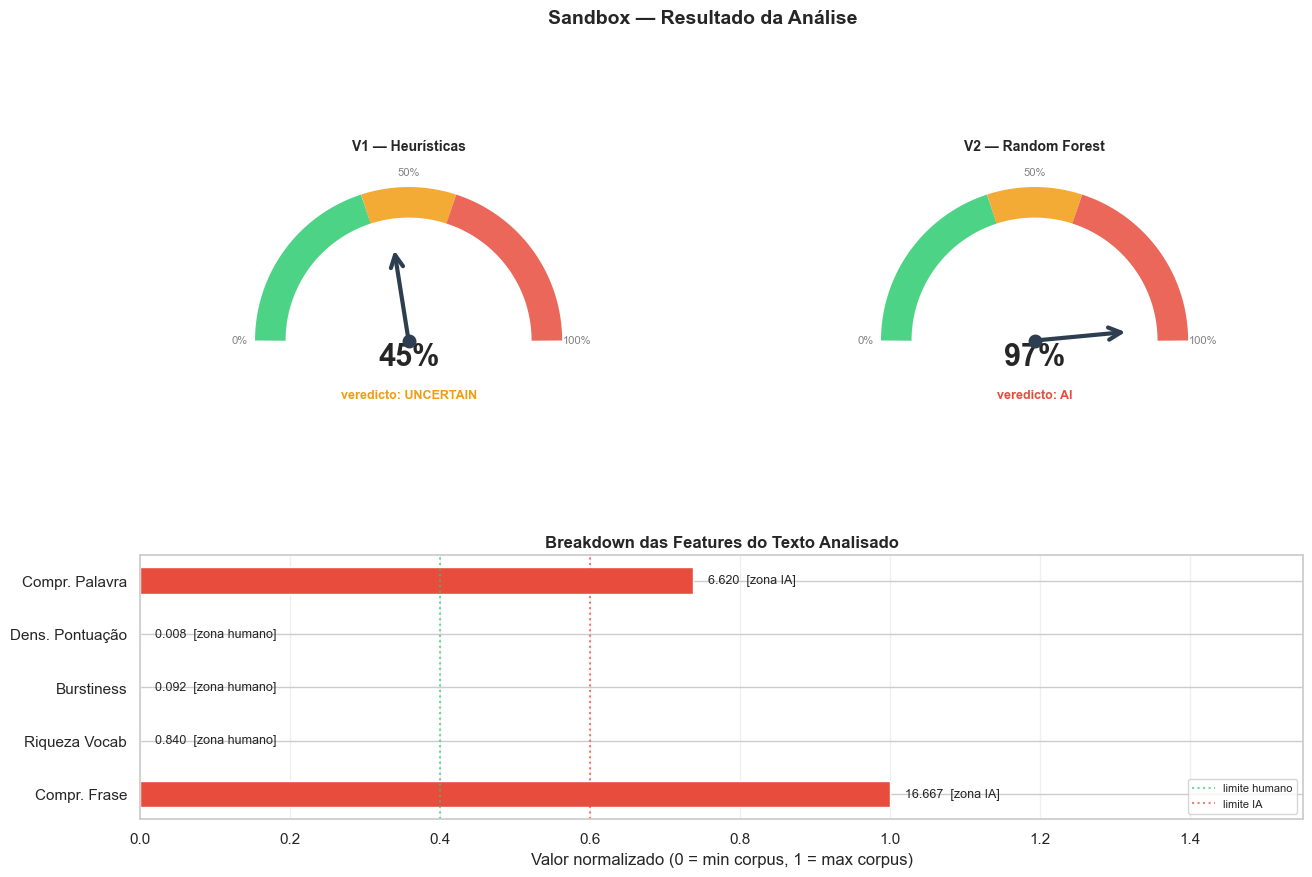

------------------------------------------------------------
Texto       : Inteligencia artificial tem transformado profundamente a maneira como orga...
Rótulo real : unknown
------------------------------------------------------------
V1 Heurísticas   | score=45%  | veredicto=uncertain
V2 Random Forest | score=97%  | veredicto=ai
------------------------------------------------------------


In [49]:
sb_text = TEXT_INPUT.strip()

# Analise V1 (heurísticas)
r_v1 = analyze_text_v1(sb_text)

# Analise V2 (Random Forest)
v2_available = False
score_v2   = 0.0
verdict_v2 = "n/a"
try:
    feats_sb = np.array([[
        r_v1["avg_sentence_length"],
        r_v1["vocabulary_richness"],
        r_v1["burstiness"],
        r_v1["punctuation_density"],
        r_v1["avg_word_length"],
    ]])
    score_v2   = float(rf_pipeline.predict_proba(feats_sb)[0][1])
    verdict_v2 = "ai" if score_v2 >= 0.5 else "human"
    v2_available = True
except Exception as exc:
    print(f"[V2 indisponível: {exc}]")

# ─── Gauge ───────────────────────────────────────────────────────────────────
GAUGE_COLORS = {"ai": "#e74c3c", "human": "#2ecc71", "uncertain": "#f39c12", "n/a": "gray"}

def _draw_gauge(ax, score, title_top, verdict):
    for s_p, e_p, col in [(0, 0.4, "#2ecc71"), (0.4, 0.6, "#f39c12"), (0.6, 1.0, "#e74c3c")]:
        theta = np.linspace(np.pi * (1 - s_p), np.pi * (1 - e_p), 80)
        ax.plot(np.cos(theta), np.sin(theta), lw=22, color=col, solid_capstyle="butt", alpha=0.85)
    needle = np.pi * (1.0 - score)
    ax.annotate("",
                xy=(0.68 * np.cos(needle), 0.68 * np.sin(needle)),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=3, mutation_scale=22))
    ax.plot(0, 0, "o", color="#2c3e50", markersize=9, zorder=5)
    ax.text(0, -0.18, f"{score:.0%}", ha="center", fontsize=22, fontweight="bold")
    ax.text(0, -0.42, f"veredicto: {verdict.upper()}",
            ha="center", fontsize=9, color=GAUGE_COLORS.get(verdict, "gray"), fontweight="bold")
    ax.text(0,  1.38, title_top, ha="center", fontsize=10, fontweight="bold")
    for pct, lbl in [(0, "0%"), (0.5, "50%"), (1.0, "100%")]:
        a = np.pi * (1.0 - pct)
        ax.text(1.22 * np.cos(a), 1.22 * np.sin(a), lbl,
                ha="center", va="center", fontsize=8, color="gray")
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-0.55, 1.55)
    ax.set_aspect("equal")
    ax.axis("off")

# ─── Feature breakdown ───────────────────────────────────────────────────────
feat_names_sb  = ["avg_sentence_length", "vocabulary_richness", "burstiness",
                  "punctuation_density", "avg_word_length"]
feat_labels_sb = ["Compr. Frase", "Riqueza Vocab", "Burstiness",
                  "Dens. Pontuação", "Compr. Palavra"]

text_feats_row = np.array([[r_v1[f] for f in feat_names_sb]])
X_aug_sb  = np.vstack([X, text_feats_row])
X_norm_sb = MinMaxScaler().fit_transform(X_aug_sb)
text_norm  = X_norm_sb[-1]

bc_feat, contrib_lbl = [], []
for val in text_norm:
    if val > 0.6:
        bc_feat.append("#e74c3c"); contrib_lbl.append("zona IA")
    elif val < 0.4:
        bc_feat.append("#2ecc71"); contrib_lbl.append("zona humano")
    else:
        bc_feat.append("#f39c12"); contrib_lbl.append("neutro")

# ─── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9))
gs  = fig.add_gridspec(2, 4, height_ratios=[1.1, 1.0], hspace=0.5, wspace=0.4)

ax_g1 = fig.add_subplot(gs[0, 0:2])
_draw_gauge(ax_g1, r_v1["score"], "V1 — Heurísticas", r_v1["verdict"])

if v2_available:
    ax_g2 = fig.add_subplot(gs[0, 2:4])
    _draw_gauge(ax_g2, score_v2, "V2 — Random Forest", verdict_v2)

ax_feat = fig.add_subplot(gs[1, :])
bars = ax_feat.barh(feat_labels_sb, text_norm, color=bc_feat, edgecolor="white", height=0.5)
ax_feat.set_xlim(0, 1.55)
ax_feat.set_xlabel("Valor normalizado (0 = min corpus, 1 = max corpus)")
ax_feat.set_title("Breakdown das Features do Texto Analisado", fontweight="bold")

for bar, lbl, fname in zip(bars, contrib_lbl, feat_names_sb):
    raw_v = r_v1[fname]
    w_b = bar.get_width()
    y_b = bar.get_y() + bar.get_height() / 2
    ax_feat.text(w_b + 0.02, y_b, f"{raw_v:.3f}  [{lbl}]", va="center", fontsize=9)

ax_feat.axvline(0.4, color="#2ecc71", linestyle=":", lw=1.5, alpha=0.7, label="limite humano")
ax_feat.axvline(0.6, color="#e74c3c", linestyle=":", lw=1.5, alpha=0.7, label="limite IA")
ax_feat.legend(fontsize=8, loc="lower right")
ax_feat.grid(True, alpha=0.3, axis="x")

plt.suptitle("Sandbox — Resultado da Análise", fontsize=14, fontweight="bold", y=1.01)
plt.show()

sep = "-" * 60
preview = sb_text[:74] + "..." if len(sb_text) > 74 else sb_text
print(sep)
print(f"Texto       : {preview}")
print(f"Rótulo real : {TRUE_LABEL}")
print(sep)
v1_s = r_v1["score"]
v1_v = r_v1["verdict"]
print(f"V1 Heurísticas   | score={v1_s:.0%}  | veredicto={v1_v}")
if v2_available:
    print(f"V2 Random Forest | score={score_v2:.0%}  | veredicto={verdict_v2}")
print(sep)

---

# 📈 Tracker de Acurácia

O tracker registra cada texto testado no sandbox (com rótulo real definido) em um arquivo JSON persistente.

Use os dados acumulados para:
- Monitorar a acurácia **por versão do modelo** ao longo do tempo
- Identificar **onde o modelo erra** (por classe, tipo de texto)
- Tomar decisões de **recalibração** baseadas em evidência real

> Defina `TRUE_LABEL = "ai"` ou `TRUE_LABEL = "human"` na célula do sandbox antes de executar.

In [50]:
TRACKER_FILE = Path("accuracy_log.json")

def _load_log():
    if TRACKER_FILE.exists():
        with open(TRACKER_FILE, encoding="utf-8") as f:
            return json.load(f)
    return []

def _save_log(log_data):
    with open(TRACKER_FILE, "w", encoding="utf-8") as f:
        json.dump(log_data, f, indent=2, ensure_ascii=False)

def add_to_tracker(text, true_label, v1_score, v1_verdict, v2_score=None, v2_verdict=None):
    if true_label == "unknown":
        print('TRUE_LABEL = "unknown" — defina "ai" ou "human" para registrar.')
        return None
    log_data = _load_log()
    entry = {
        "timestamp":  datetime.now().isoformat(timespec="seconds"),
        "preview":    text[:100],
        "true_label": true_label,
        "v1_score":   round(v1_score, 4),
        "v1_verdict": v1_verdict,
        "v1_correct": v1_verdict == true_label,
        "v2_score":   round(v2_score, 4) if v2_score is not None else None,
        "v2_verdict": v2_verdict,
        "v2_correct": (v2_verdict == true_label) if (v2_verdict and v2_verdict != "n/a") else None,
    }
    log_data.append(entry)
    _save_log(log_data)
    print(f"Registrado! Total no log: {len(log_data)} textos.")
    return entry

print("Tracker pronto!")
print(f"Arquivo de log: {TRACKER_FILE.resolve()}")

Tracker pronto!
Arquivo de log: C:\Users\Marcus\PYTHON\machine-learning\ai-detector\notebooks\accuracy_log.json


In [51]:
# Registra o resultado do sandbox atual no log
# (só registra se TRUE_LABEL != "unknown")
if "r_v1" not in globals():
    print("Execute as células do Sandbox primeiro.")
else:
    add_to_tracker(
        text       = sb_text,
        true_label = TRUE_LABEL,
        v1_score   = r_v1["score"],
        v1_verdict = r_v1["verdict"],
        v2_score   = score_v2 if v2_available else None,
        v2_verdict = verdict_v2 if v2_available else None,
    )

TRUE_LABEL = "unknown" — defina "ai" ou "human" para registrar.


In [52]:
from IPython.display import display as ipy_display

log_data = _load_log()

if not log_data:
    print("Log vazio — defina TRUE_LABEL no sandbox, execute e depois registre acima.")
else:
    log_df = pd.DataFrame(log_data)
    log_df["timestamp"] = pd.to_datetime(log_df["timestamp"])
    n = len(log_df)

    v1_acc = log_df["v1_correct"].mean()
    v2_rows = log_df[log_df["v2_correct"].notna()]
    v2_acc = v2_rows["v2_correct"].astype(float).mean() if len(v2_rows) > 0 else None

    print("=" * 56)
    print(f"  TRACKER DE ACURÁCIA  —  {n} textos testados")
    print("=" * 56)
    print(f"  V1 Heurísticas   ->  {v1_acc:.0%}  ({int(log_df['v1_correct'].sum())}/{n})")
    if v2_acc is not None:
        n2 = len(v2_rows)
        print(f"  V2 Random Forest ->  {v2_acc:.0%}  ({int(v2_rows['v2_correct'].sum())}/{n2})")
    print()

    print("  Por classe (V1):")
    for cls in log_df["true_label"].unique():
        sub = log_df[log_df["true_label"] == cls]
        cls_acc = sub["v1_correct"].mean()
        print(f"    {cls:8s}  ->  {cls_acc:.0%}  ({int(sub['v1_correct'].sum())}/{len(sub)})")
    print()

    disp_cols = ["timestamp", "true_label", "v1_verdict", "v1_correct", "v1_score"]
    if "v2_verdict" in log_df.columns:
        disp_cols += ["v2_verdict", "v2_correct", "v2_score"]
    recent = log_df[disp_cols].tail(8).copy()
    recent["timestamp"] = recent["timestamp"].dt.strftime("%d/%m %H:%M")

    correct_cols = [c for c in ["v1_correct", "v2_correct"] if c in recent.columns]
    styled = recent.style.map(
        lambda v: "background-color:#d4edda" if v is True else
                  "background-color:#f8d7da" if v is False else "",
        subset=correct_cols
    )
    ipy_display(styled)

    if n >= 2:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

        log_df["v1_cumul"] = log_df["v1_correct"].expanding().mean()
        ax1.plot(range(1, n + 1), log_df["v1_cumul"], marker="o",
                 color="#3498db", lw=2.5, label="V1 Heurísticas")
        if v2_acc is not None:
            v2s = v2_rows.copy()
            v2s["v2_cumul"] = v2s["v2_correct"].astype(float).expanding().mean()
            ax1.plot(range(1, len(v2s) + 1), v2s["v2_cumul"], marker="s",
                     color="#e67e22", lw=2.5, label="V2 Random Forest")
        ax1.axhline(0.5, color="gray", linestyle="--", lw=1, label="Baseline 50%")
        ax1.set_xlabel("Nº de textos testados")
        ax1.set_ylabel("Acurácia acumulada")
        ax1.set_ylim(0, 1.05)
        ax1.set_title("Acurácia Acumulada ao Longo dos Testes", fontweight="bold")
        ax1.legend()

        score_stats = log_df.groupby("true_label")["v1_score"].agg(["mean", "std"]).reset_index()
        bar_c = ["#e74c3c" if row["true_label"] == "ai" else "#2ecc71"
                 for _, row in score_stats.iterrows()]
        ax2.bar(score_stats["true_label"], score_stats["mean"],
                yerr=score_stats["std"], color=bar_c, capsize=8,
                error_kw={"linewidth": 2}, edgecolor="white")
        ax2.axhline(0.5, color="gray", linestyle="--", lw=1.5)
        ax2.axhline(0.6, color="#e74c3c", linestyle=":", lw=1, label="Limiar IA")
        ax2.axhline(0.4, color="#2ecc71", linestyle=":", lw=1, label="Limiar Humano")
        ax2.set_ylabel("Score V1 médio (± std)")
        ax2.set_title("Score Médio por Classe — V1", fontweight="bold")
        ax2.set_ylim(0, 1.1)
        ax2.legend(fontsize=8)

        plt.suptitle("Tracker de Acurácia — Métricas Acumuladas", fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

    print()
    print(f"Log salvo em: {TRACKER_FILE.resolve()}")
    print("Para recalibrar: ajuste os limiares em analyze_text_v1() com base nos erros acumulados.")

Log vazio — defina TRUE_LABEL no sandbox, execute e depois registre acima.


## 📋 Resumo da Fase 2

### O que fizemos
- Reaproveitamos as 5 features da Fase 1 (sem criar novas features ainda)
- Treinamos 3 classificadores: Logistic Regression, Random Forest e Gradient Boosting
- Avaliamos com Leave-One-Out (metodologia correta para datasets pequenos)
- Identificamos as features mais importantes via Gini impurity (Random Forest)
- Exportamos o modelo para uso na API

### O que aprendemos
- O ML aprende **combinações** de features que as regras manuais não capturam
- `burstiness` e `avg_word_length` tendem a ser as features mais discriminativas
- Com apenas 6 exemplos, os resultados são **indicativos** — não definitivos

### Limitações atuais
- **Corpus muito pequeno** — precisamos de dados reais rotulados para treinar com confiança
- **Features ainda superficiais** — não capturamos semântica, coerência ou fluxo do texto

---

# FASE 3 — Perplexidade com Modelos de Linguagem *(planejada)*

## 📖 O que é Perplexidade?

**Perplexidade** mede o quão "surpreso" um modelo de linguagem fica ao ler um texto.  
A intuição central: **LLMs geram textos que são previsíveis para outros LLMs**.

- Texto de IA → **baixa perplexidade** (o modelo reconhece os padrões que ele mesmo aprendeu)
- Texto humano → **alta perplexidade** (humanos são mais criativos e imprevisíveis)

### Fórmula

$$PP(W) = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i \mid w_1, ..., w_{i-1})\right)$$

Onde:
- $W$ = texto com $N$ tokens
- $P(w_i \mid \text{contexto})$ = probabilidade do próximo token dado pelo modelo

### Stack planejada

```python
# Opção A: HuggingFace (mais poderoso, requer GPU ou paciência)
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Opção B: modelo leve via API (mais rápido para demos)
# Ex: usar log-probs da OpenAI API ou da Anthropic API
```

## 🗺️ Roadmap Completo

| Fase | O que muda | Features principais |
|------|------------|--------------------|
| **1** ✅ | Heurísticas manuais | Comprimento, TTR, burstiness, pontuação |
| **2** 🔄 | Classificador ML | Mesmas features + modelo que aprende combinações |
| **3** 🔜 | Perplexidade GPT-2 | Probabilidade dos tokens — semântica do texto |
| **4** 🔜 | Ensemble | Combina heurísticas + ML + perplexidade |
| **5** 🔜 | Fine-tuning | Modelo treinado especificamente para detecção |

> Este notebook será atualizado a cada nova fase implementada.